# M9 - Dispatching Policy Comparison

**Goal.** Compare five dispatching policies on the same M2-M8 fab simulator:
the locked FIFO default, three alternative priority rules (earliest due date,
critical ratio, queue-time-aware), and an opt-in bottleneck-WIP release
control. Every comparison is CRN-paired against FIFO on the same draw table,
so a policy's effect is isolated from the noise of the random arrival and
processing-time streams.

**Structure.**
1. The five policies in plain language, the due-date model and its
   calibration, and the CRN pairing discipline that makes paired deltas
   trustworthy (with an inline proof: FIFO-vs-FIFO paired on itself gives an
   exact zero delta).
2. The paired comparison: `compare_policies` run against two demand regimes
   (baseline and arrival rate x1.15), with 95% confidence intervals on every
   metric's delta.
3. The decision table: which policy wins which business objective, in which
   regime, with a measured caveat (never hand-written) for what the winner
   trades away.
4. The honest null result: `queue_time_aware` produces an EXACTLY zero
   violation-rate delta at the locked configuration. This section shows the
   measurement, explains the structural root cause, and then tests one
   CRN-paired what-if stress scenario to see whether the rule ever binds.
5. Closing: what M9 adds, limits, and pointers to the check scripts.

**Honest scope.** This is a stylized single-product wafer-fab simulation
(`src/generator`); all data is synthetic, generated with fixed seeds. Rankings
below hold under the stated assumptions (locked route, station means, due-date
calibration, cost rates) and are not a claim about any real fabrication line.
Dollar figures are illustrative constants used only to rank policies against
each other on a common scale, not real fab prices. The stress scenario in
Section 5 is an explicit what-if (a config copy with a scenario-only change);
it does not alter the locked default line used everywhere else in this
project.


In [1]:
%matplotlib inline
import sys
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})

NB_START = time.time()

ROOT = Path("..")
for p in ["src", "src/generator", "src/bottleneck", "src/monitoring",
          "src/decision", "src/quality"]:
    sys.path.insert(0, str(ROOT / p))

from factory_generator import (
    default_config, draw_randoms, simulate, theoretical_utilization,
    compute_due_date, raw_process_time_of_route, ReleaseControlConfig,
)
from queue_time import DEFAULT_WINDOW_HOURS, flag_violations
from dispatch_whatif import (
    TREATMENT_CONFIGS, DEMAND_REGIMES, DEFAULT_RELEASE_THRESHOLD,
    OBJECTIVE_METRICS, OBJECTIVE_CAVEAT_METRIC, METRICS_HIGHER_IS_BETTER,
    paired_policy_comparison, compare_policies, summarize_policy_comparison,
    decision_table,
)

FIG = ROOT / "reports" / "figures"; FIG.mkdir(parents=True, exist_ok=True)

cfg = default_config()
print(f"route: {cfg.route}")
print(f"flow_factor (due date multiplier): {cfg.flow_factor}")
print(f"raw route time: {raw_process_time_of_route(cfg):.2f} h")


route: ['CLEAN', 'FURNACE', 'DEPO', 'LITHO', 'ETCH', 'LITHO', 'IMPLANT', 'METRO']
flow_factor (due date multiplier): 1.8
raw route time: 10.00 h


## Step 1 - The five policies, the due-date model, and CRN pairing

**The policies compared** (all against the locked FIFO baseline, see
`src/generator/factory_generator.py`'s `_dispatch_order`):

| Policy | Rule | Where it applies |
|---|---|---|
| `fifo` (locked default) | Serve in arrival order | Every station |
| `edd` | Serve the earliest due date first | Every station |
| `critical_ratio` | Serve the smallest (due minus now) / remaining work first (least slack per unit of work left) | Every station |
| `queue_time_aware` | Serve the least remaining post-litho window slack first | ETCH and IMPLANT only (falls back to FIFO elsewhere) |
| `release_control` (opt-in) | FIFO dispatch, plus a gate that holds new lots out of CLEAN once LITHO WIP (queued + in-process, both re-entrant visits) reaches a threshold | Release into the line, not station dispatch |

**Due-date model.** Every lot's due date is assigned at arrival:
`due = arrival_time + flow_factor * raw_route_time`, where `raw_route_time` is
the sum of each route step's MEAN processing time (a fixed, config-only
quantity, no random draws). `flow_factor = 1.8` was chosen by sweeping the
realized cycle-time distribution against the FIFO baseline until the on-time
rate landed in a "discriminating" 70-95% band (neither saturating near 0% nor
100%), so different dispatch policies can visibly move it. The baseline FIFO
on-time rate at this calibration is 0.858.

**Release-control threshold.** `litho_wip_threshold = 14` was picked by a
documented sweep (see `dispatch_whatif.py`'s module docstring): it still
visibly binds (cycle time and violation rate move relative to lower
thresholds) while throughput and on-time rate sit within noise of no control
at all, i.e. it caps bottleneck WIP without costing output.

**CRN pairing discipline.** Every replication draws ONE random-numbers table
(`draw_randoms(cfg, seed0 + rep)`) from a config that fixes the arrival rate,
route, and processing-time distributions for the regime. FIFO and every
treatment configuration in that regime are simulated against that SAME table,
so a configuration's `queue_discipline` (or `release_control`) is the ONLY
thing that differs between runs. `dispatch_check.py` GATE 4 proves this holds
even across different dispatch policies: with one shared draw table, every
lot's realized processing-time draw at each (station, visit) is bit-identical
between a FIFO run and an EDD run, because draws are indexed by (lot, route
step), never by queue position - reordering a station's pending list cannot
desynchronize the pairing.

The cell below shows the practical consequence directly: pairing the FIFO
baseline against itself (same policy, same table) must give an EXACT zero
delta on every metric. This is not a tolerance check, it is a bit-exact
identity, and it is the foundation every paired delta in this notebook rests
on.


In [2]:
base_cfg = default_config()
fifo_vs_fifo = paired_policy_comparison(base_cfg, "fifo", "baseline",
                                         arrival_factor=1.0, n_reps=5, seed0=8000)
metric_cols = [c for c in fifo_vs_fifo.columns if c.startswith("d_")]
max_abs_delta = fifo_vs_fifo[metric_cols].abs().to_numpy().max()
print("FIFO-vs-FIFO paired comparison (5 reps, same draw table):")
print(f"  max |delta| across every metric and every rep = {max_abs_delta:.2e}")
print(f"  exact zero: {max_abs_delta == 0.0}")


FIFO-vs-FIFO paired comparison (5 reps, same draw table):
  max |delta| across every metric and every rep = 0.00e+00
  exact zero: True


## Step 2 - The paired comparison

`compare_policies` runs the CRN-paired FIFO-vs-treatment comparison for every
policy in `TREATMENT_CONFIGS` (`edd`, `critical_ratio`, `queue_time_aware`,
`release_control`), in every regime in `DEMAND_REGIMES` (`baseline`,
`demand x1.15`), at `n_reps=30` (the module default; matches the CI widths
already validated by `dispatch_whatif_check.py`). Runtime is measured below.

Metrics per replication: mean lot cycle time, output (completed lots),
on-time delivery rate, post-litho violation rate, mean lot yield, congestion
cost, and total cost (congestion + scrap). Deltas are treatment minus FIFO
baseline, paired within the same replication and draw table; a 95% CI comes
from the t-distribution across the 30 paired deltas (same recipe as
`counterfactual.summarize`).


In [3]:
t0 = time.time()
paired = compare_policies(base_cfg, n_reps=30, seed0=8000)
summary = summarize_policy_comparison(paired)
elapsed = time.time() - t0
print(f"compare_policies runtime: {elapsed:.1f} s "
      f"({len(DEMAND_REGIMES)} regimes x {len(TREATMENT_CONFIGS)} policies x 30 reps)")
summary.head(12)


compare_policies runtime: 46.4 s (2 regimes x 4 policies x 30 reps)


,regime,policy,metric,n,mean_delta,ci_lo,ci_hi
0,baseline,edd,mean_cycle_time,30,-0.604636,-0.714350,-0.494921
1,baseline,edd,output,30,0.166667,-0.799539,1.132873
2,baseline,edd,on_time_rate,30,0.054009,0.048117,0.059902
3,baseline,edd,violation_rate,30,0.014944,0.011227,0.018661
4,baseline,edd,mean_lot_yield,30,-0.001725,-0.002255,-0.001196
5,baseline,edd,congestion_cost,30,-7522.963293,-9453.185316,-5592.741270
6,baseline,edd,scrap_cost,30,9400.000000,6515.036026,12284.963974
7,baseline,edd,total_cost,30,1877.036707,-1607.575261,5361.648676
8,baseline,critical_ratio,mean_cycle_time,30,-0.355509,-0.463356,-0.247663
9,baseline,critical_ratio,output,30,0.333333,-0.658654,1.325320


**Delta-vs-FIFO figure.** For every metric, one panel showing each
policy's mean paired delta against FIFO with a 95% CI whisker, split by
regime. Bars crossing zero mean the policy's effect on that metric is not
significant at this sample size.


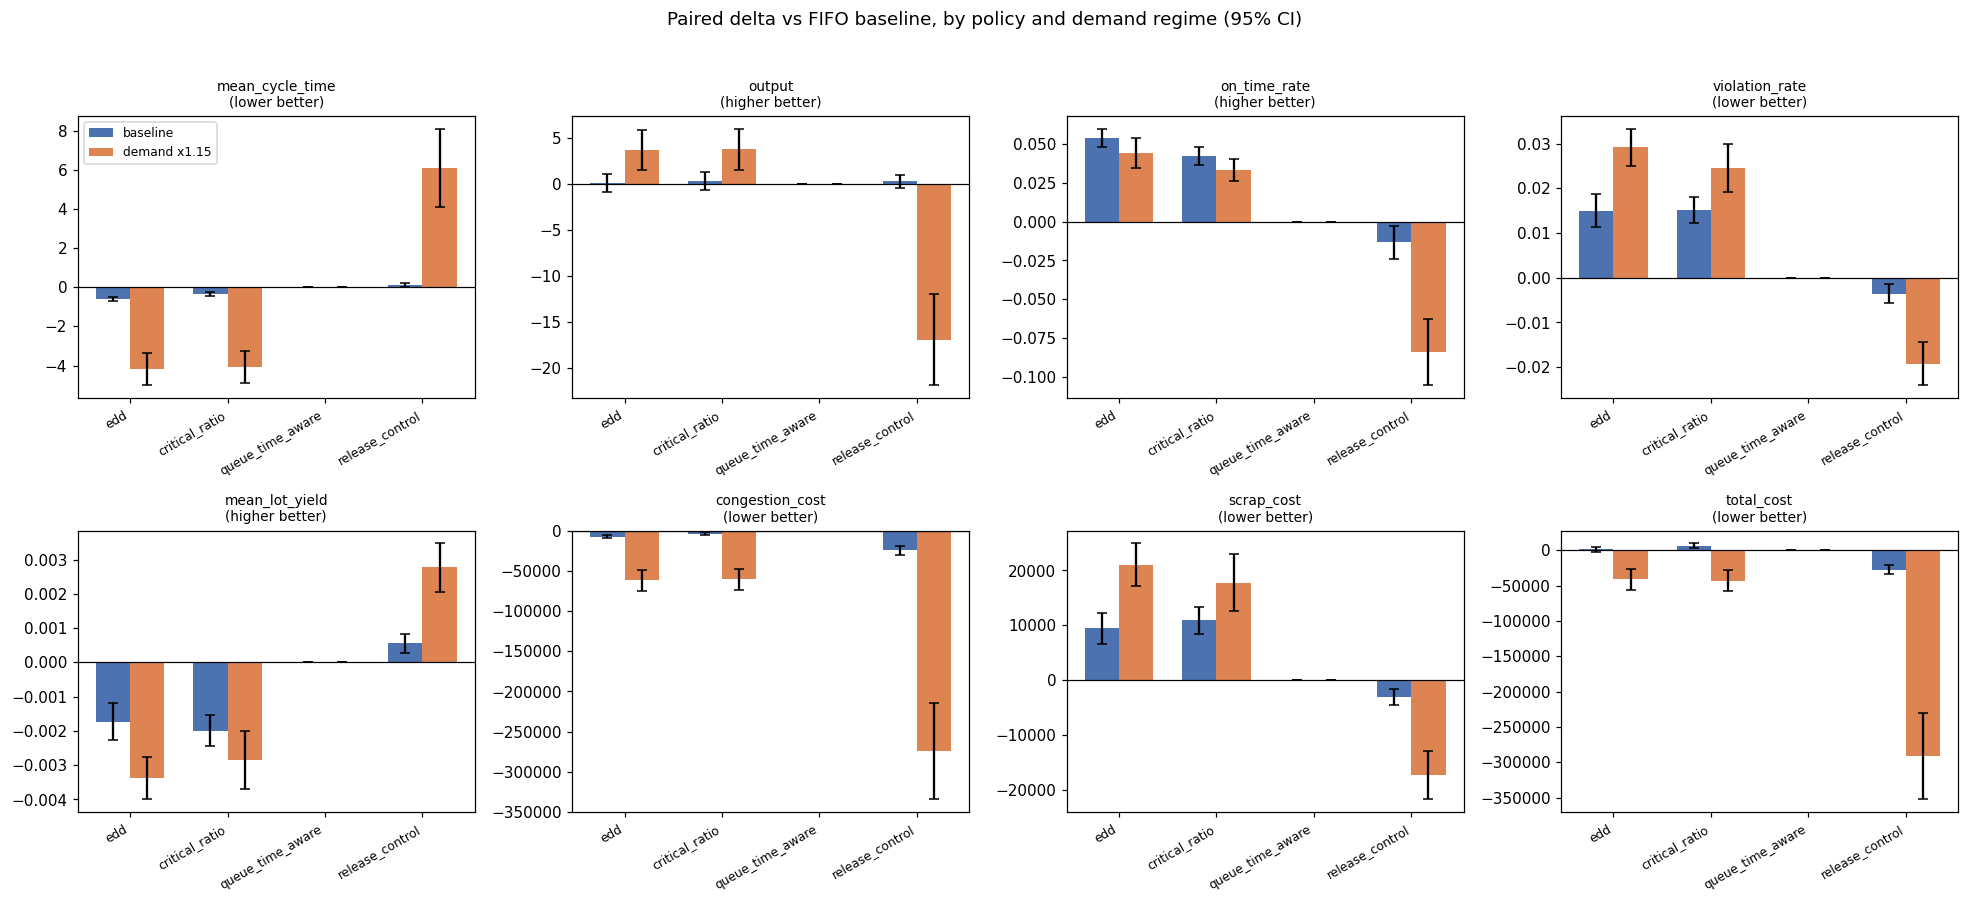

saved reports/figures/m9_policy_deltas.png


In [4]:
metrics_order = list(METRICS_HIGHER_IS_BETTER)
regimes_order = list(DEMAND_REGIMES)
policies_order = list(TREATMENT_CONFIGS)

fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharex=False)
colors = {"baseline": "#4C72B0", "demand x1.15": "#DD8452"}

for ax, metric in zip(axes.flat, metrics_order):
    x = np.arange(len(policies_order))
    width = 0.35
    for i, regime in enumerate(regimes_order):
        sub = summary[(summary["metric"] == metric) & (summary["regime"] == regime)]
        sub = sub.set_index("policy").reindex(policies_order)
        means = sub["mean_delta"].to_numpy()
        lo = means - sub["ci_lo"].to_numpy()
        hi = sub["ci_hi"].to_numpy() - means
        offset = (i - 0.5) * width
        ax.bar(x + offset, means, width, yerr=[lo, hi], capsize=3,
               color=colors[regime], label=regime if metric == metrics_order[0] else None)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(policies_order, rotation=30, ha="right", fontsize=8)
    higher_better = METRICS_HIGHER_IS_BETTER[metric]
    ax.set_title(f"{metric}\n({'higher better' if higher_better else 'lower better'})", fontsize=9)

axes.flat[0].legend(loc="upper left", fontsize=8)
fig.suptitle("Paired delta vs FIFO baseline, by policy and demand regime (95% CI)", y=1.02)
fig.tight_layout()
fig.savefig(FIG / "m9_policy_deltas.png", dpi=150, bbox_inches="tight")
plt.show()
print("saved reports/figures/m9_policy_deltas.png")


## Step 3 - The decision table

`decision_table` reads off, per regime and per business objective (cycle
time, on-time delivery, yield risk, total cost), which policy has the best
mean delta on that objective's metric, whether the win is significant (95% CI
excludes zero), and a caveat: the measured delta of a second metric for that
SAME winning policy (e.g. the on-time cost of a total-cost win), never
hand-written.

The winner depends on the business objective and the demand regime, not on a
single "best policy": EDD wins on speed and delivery, release control wins on
yield risk and total cost, and each win comes with a measured trade-off.


In [5]:
table = decision_table(summary)
display_cols = ["regime", "objective", "winner", "mean_delta", "ci_lo", "ci_hi",
                 "significant", "caveat_metric", "caveat_delta"]
table[display_cols]


,regime,objective,winner,mean_delta,ci_lo,ci_hi,significant,caveat_metric,caveat_delta
0,baseline,cycle time,edd,-0.604636,-0.714350,-0.494921,True,violation_rate,0.014944
1,baseline,on-time delivery,edd,0.054009,0.048117,0.059902,True,mean_cycle_time,-0.604636
2,baseline,yield risk,release_control,-0.003538,-0.005591,-0.001485,True,mean_cycle_time,0.114292
3,baseline,total cost,release_control,-27604.799449,-33816.342016,-21393.256882,True,on_time_rate,-0.013446
4,demand x1.15,cycle time,edd,-4.176296,-4.989835,-3.362757,True,violation_rate,0.029112
5,demand x1.15,on-time delivery,edd,0.044577,0.034938,0.054216,True,mean_cycle_time,-4.176296
6,demand x1.15,yield risk,release_control,-0.019189,-0.023978,-0.014401,True,mean_cycle_time,6.092122
7,demand x1.15,total cost,release_control,-290973.382003,-352468.073262,-229478.690743,True,on_time_rate,-0.083963


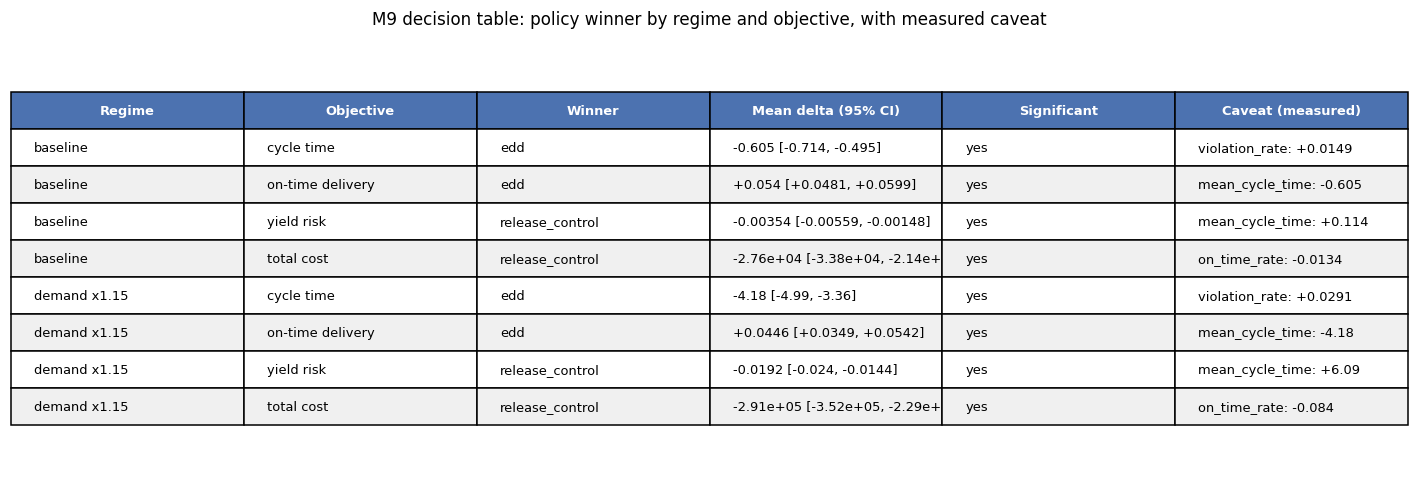

saved reports/figures/m9_decision_table.png


In [6]:
fig, ax = plt.subplots(figsize=(13, 4.5))
ax.axis("off")

col_labels = ["Regime", "Objective", "Winner", "Mean delta (95% CI)",
              "Significant", "Caveat (measured)"]
cell_text = []
for _, row in table.iterrows():
    delta_str = f"{row['mean_delta']:+.3g} [{row['ci_lo']:+.3g}, {row['ci_hi']:+.3g}]"
    caveat_str = f"{row['caveat_metric']}: {row['caveat_delta']:+.3g}"
    cell_text.append([row["regime"], row["objective"], row["winner"], delta_str,
                       "yes" if row["significant"] else "no", caveat_str])

tbl = ax.table(cellText=cell_text, colLabels=col_labels, loc="center", cellLoc="left")
tbl.auto_set_font_size(False)
tbl.set_fontsize(8.5)
tbl.scale(1, 1.8)
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor("#4C72B0")
        cell.set_text_props(color="white", weight="bold")
    elif r % 2 == 0:
        cell.set_facecolor("#F0F0F0")

ax.set_title("M9 decision table: policy winner by regime and objective, with measured caveat",
             fontsize=11, pad=14)
fig.tight_layout()
fig.savefig(FIG / "m9_decision_table.png", dpi=150, bbox_inches="tight")
plt.show()
print("saved reports/figures/m9_decision_table.png")


**Reading the table.** In the baseline regime, EDD cuts mean cycle time
by about 0.60 h and lifts on-time delivery by 5.4 percentage points, but its
own caveat shows post-litho violation rate rising by about 0.015; release
control cuts yield-risk violations by about 0.35 percentage points and total
cost by about $27,600, but its caveat shows on-time delivery falling by about
1.3 percentage points. Under the higher-demand regime (arrival rate x1.15)
the same pattern holds and widens: EDD's cycle-time and on-time gains grow
(-4.18 h, +4.5 pp), and release control's cost and violation-rate gains grow
sharply (-$290,973 total cost, -1.9 pp violations), at a steeper on-time cost
(-8.4 pp). Every cell's CI excludes zero, so "significant" is true throughout
this table; the trade-off is real, not noise, and the right policy depends on
which objective the business is optimizing for.


## Step 4 - When a dispatch rule does nothing

`queue_time_aware` reorders ETCH and IMPLANT's pending-lot queues by least
remaining post-litho window slack. Measured against the locked configuration,
its effect on the post-litho violation rate is an EXACT zero, in every one of
the 30 baseline-regime replications and every one of 30 `demand x1.15`
replications. This is not "not statistically significant"; it is a bit-exact
zero delta, and CRN pairing is what lets us say that with certainty instead
of reporting a confidence interval that merely happens to straddle zero.


In [7]:
qta_rows = summary[(summary["policy"] == "queue_time_aware")
                    & (summary["metric"] == "violation_rate")]
qta_rows[["regime", "policy", "metric", "n", "mean_delta", "ci_lo", "ci_hi"]]


,regime,policy,metric,n,mean_delta,ci_lo,ci_hi
19,baseline,queue_time_aware,violation_rate,30,0.0,0.0,0.0
51,demand x1.15,queue_time_aware,violation_rate,30,0.0,0.0,0.0


**Root cause.** `_dispatch_order`'s `queue_time_aware` branch sorts a
station's pending lots by ascending slack, where
`slack = W - (now - qentry)` (`W` is the fixed post-litho window,
`DEFAULT_WINDOW_HOURS`). At any single dispatch instant, `now` is the SAME
value for every pending lot being sorted, so `W - now` is a constant offset
across the whole comparison: ordering by ascending slack is mathematically
identical to ordering by ascending `qentry`, i.e. FIFO order, for any queue
state at any station, at any utilization. The rule cannot reorder anything at
ETCH or IMPLANT because its priority key is a monotonic function of arrival
order alone, not an independent signal.

This is confirmed directly below: pairing FIFO against `queue_time_aware` on
the SAME draw table, the dispatched lot order at ETCH is identical, row for
row, even when the queue is heavily loaded.


In [8]:
etch_util = theoretical_utilization(base_cfg)["ETCH"]
implant_util = theoretical_utilization(base_cfg)["IMPLANT"]

draws0 = draw_randoms(base_cfg, 8000)
log_fifo0, _, _ = simulate(base_cfg, draws0)

cfg_qta0 = default_config()
cfg_qta0.queue_discipline = "queue_time_aware"
log_qta0, _, _ = simulate(cfg_qta0, draws0)

rows = []
for station in ("ETCH", "IMPLANT"):
    fifo_rows = log_fifo0[log_fifo0["station"] == station].sort_values("process_start_time")
    qta_rows_ = log_qta0[log_qta0["station"] == station].sort_values("process_start_time")
    order_diff = int((fifo_rows["lot_id"].to_numpy() != qta_rows_["lot_id"].to_numpy()).sum())
    n_rows = len(fifo_rows)
    max_pending = 0
    qe = fifo_rows["queue_entry_time"].to_numpy()
    ps = fifo_rows["process_start_time"].to_numpy()
    for i in range(len(qe)):
        pending = int(((qe <= qe[i]) & (ps > qe[i])).sum())
        max_pending = max(max_pending, pending)
    rho = theoretical_utilization(base_cfg)[station]
    rows.append({"station": station, "slot_utilization_rho": round(rho, 3),
                 "n_tools": base_cfg.stations[station].n_tools,
                 "max_simultaneous_pending_lots": max_pending,
                 "dispatch_rows_checked": n_rows,
                 "dispatch_order_rows_that_differ_fifo_vs_qta": order_diff})

pd.DataFrame(rows)


,station,slot_utilization_rho,n_tools,max_simultaneous_pending_lots,dispatch_rows_checked,dispatch_order_rows_that_differ_fifo_vs_qta
0,ETCH,0.50,2,3,1464,0
1,IMPLANT,0.55,2,5,1464,0


**One CRN-paired stress test.** The root cause above is structural
(slack is a monotonic function of arrival order at these two stations), so no
amount of queueing pressure should make `queue_time_aware` diverge from FIFO
there. To test that claim rather than assume it, this section builds a
what-if scenario, NOT a change to the locked default line: a config copy with
ETCH's mean processing time scaled up 1.8x (pushing ETCH's slot utilization
from rho ~ 0.50 to rho ~ 0.90, well past the point queues visibly form, see
the `max_simultaneous_pending_lots` column above) at the higher `demand
x1.15`-style arrival factor. This is the minimal stress that produces heavy,
sustained ETCH queueing while keeping the rest of the line (including the
LITHO bottleneck) at its normal calibration.


In [9]:
stress_cfg = default_config()
stress_cfg.stations["ETCH"].pt_mean *= 1.8
stress_rho = theoretical_utilization(stress_cfg)
print("Stress scenario: ETCH pt_mean x1.8 (what-if only, not the locked default)")
print(f"  ETCH slot utilization (rho):    default {theoretical_utilization(default_config())['ETCH']:.3f}"
      f"  ->  stressed {stress_rho['ETCH']:.3f}")
print(f"  LITHO slot utilization (rho):   {stress_rho['LITHO']:.3f}  (bottleneck unchanged)")

t1 = time.time()
stress_paired = paired_policy_comparison(stress_cfg, "queue_time_aware", "etch_stress",
                                          arrival_factor=1.0, n_reps=30, seed0=8000)
stress_summary = summarize_policy_comparison(stress_paired)
print(f"stress scenario runtime: {time.time() - t1:.1f} s (30 reps)")

viol_row = stress_summary[stress_summary["metric"] == "violation_rate"].iloc[0]
print()
print("queue_time_aware violation_rate delta under ETCH stress (30 reps, seed0=8000):")
print(f"  mean_delta = {viol_row['mean_delta']:+.5f}   "
      f"95% CI = [{viol_row['ci_lo']:+.5f}, {viol_row['ci_hi']:+.5f}]")


Stress scenario: ETCH pt_mean x1.8 (what-if only, not the locked default)
  ETCH slot utilization (rho):    default 0.500  ->  stressed 0.900
  LITHO slot utilization (rho):   0.850  (bottleneck unchanged)
stress scenario runtime: 5.6 s (30 reps)

queue_time_aware violation_rate delta under ETCH stress (30 reps, seed0=8000):
  mean_delta = +0.00000   95% CI = [+0.00000, +0.00000]


In [10]:
draws_s = draw_randoms(stress_cfg, 8000)
log_fifo_s, _, _ = simulate(stress_cfg, draws_s)

cfg_qta_s = default_config()
cfg_qta_s.stations["ETCH"].pt_mean *= 1.8
cfg_qta_s.queue_discipline = "queue_time_aware"
log_qta_s, _, _ = simulate(cfg_qta_s, draws_s)

etch_fifo_s = log_fifo_s[log_fifo_s["station"] == "ETCH"].sort_values("process_start_time")
etch_qta_s = log_qta_s[log_qta_s["station"] == "ETCH"].sort_values("process_start_time")
order_diff_s = int((etch_fifo_s["lot_id"].to_numpy() != etch_qta_s["lot_id"].to_numpy()).sum())

qe = etch_fifo_s["queue_entry_time"].to_numpy()
ps = etch_fifo_s["process_start_time"].to_numpy()
max_pending_s = 0
for i in range(len(qe)):
    pending = int(((qe <= qe[i]) & (ps > qe[i])).sum())
    max_pending_s = max(max_pending_s, pending)

print(f"ETCH under stress: rho={stress_rho['ETCH']:.3f}, "
      f"max simultaneous pending lots = {max_pending_s} "
      f"(baseline was {rows[0]['max_simultaneous_pending_lots']})")
print(f"ETCH dispatch order rows that differ, fifo vs queue_time_aware: "
      f"{order_diff_s} of {len(etch_fifo_s)}")


ETCH under stress: rho=0.900, max simultaneous pending lots = 27 (baseline was 3)
ETCH dispatch order rows that differ, fifo vs queue_time_aware: 0 of 1464


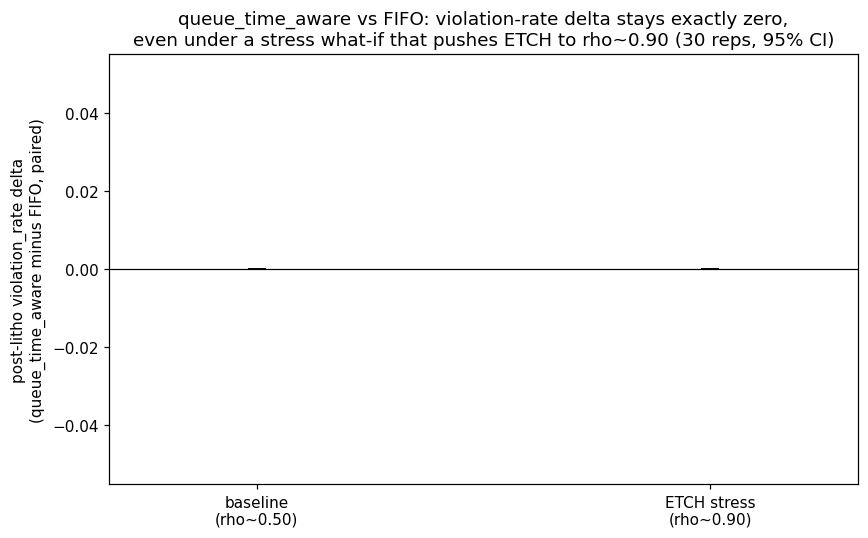

saved reports/figures/m9_qta_stress.png


In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
scenarios = ["baseline\n(rho~0.50)", "ETCH stress\n(rho~0.90)"]
deltas = [0.0, viol_row["mean_delta"]]
ci_lo = [0.0, viol_row["ci_lo"]]
ci_hi = [0.0, viol_row["ci_hi"]]
lo_err = [d - l for d, l in zip(deltas, ci_lo)]
hi_err = [h - d for d, h in zip(deltas, ci_hi)]

ax.bar(scenarios, deltas, yerr=[lo_err, hi_err], capsize=6, color="#55A868", width=0.5)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("post-litho violation_rate delta\n(queue_time_aware minus FIFO, paired)")
ax.set_title("queue_time_aware vs FIFO: violation-rate delta stays exactly zero,\n"
             "even under a stress what-if that pushes ETCH to rho~0.90 (30 reps, 95% CI)")
fig.tight_layout()
fig.savefig(FIG / "m9_qta_stress.png", dpi=150, bbox_inches="tight")
plt.show()
print("saved reports/figures/m9_qta_stress.png")


**Outcome: the rule STILL does nothing, even under stress.** Pushing
ETCH to rho ~ 0.90 (well past the point queues visibly and heavily form, up
to dozens of lots simultaneously pending) does not move the violation-rate
delta off exactly zero, and the dispatched lot order at ETCH is still
identical between FIFO and `queue_time_aware`, row for row. This confirms the
root cause is not "queues are usually too short to matter" but a structural
identity: `queue_time_aware`'s priority key at these two stations is a
monotonic transform of arrival time, so it can never produce an order
different from FIFO, at any queue depth. The lesson to take from this is not
that `queue_time_aware` is a bad rule in general (it operationalizes a real
idea, protect lots closest to violating their post-litho window), but that
this specific implementation only binds where slack varies independently of
arrival order across pending lots at the same instant, and that condition
does not hold at ETCH/IMPLANT under this simulator's dispatch mechanism
(queues drain synchronously the moment a tool frees, so all currently-pending
lots share a fixed processing-time window relative to their own arrival, not
one another). Measuring nothing, with an exact-zero result instead of a
CI that happens to straddle zero, is itself the finding: priority rules only
change outcomes where their priority key carries information beyond what
FIFO already encodes, and CRN pairing is what makes that distinction provable
rather than a guess from noisy point estimates.


## Step 5 - Closing

**What M9 adds.** A configurable dispatch layer (`queue_discipline`, due
dates, opt-in bottleneck-WIP release control) turns "which policy should the
fab run" from a slogan into a measured, CRN-paired trade-off: EDD buys cycle
time and on-time delivery at some yield-risk cost; release control buys yield
risk and total cost at some on-time cost; and `queue_time_aware`, this
implementation's version of a queue-aware rule, provably does nothing at the
two stations it targets, a negative result worth reporting precisely because
CRN pairing lets it be stated as an exact zero rather than an ambiguous null.

**Limits.** All rankings hold at the locked route, station means, due-date
calibration (`flow_factor=1.8`), and cost rates; the ETCH-stress scenario in
Section 4 is an explicit what-if, not a change to the locked default line
used everywhere else in this project. Dollar figures are illustrative
constants for internal ranking, not real fab prices. `queue_time_aware` was
tested at one implementation of "slack"; a different formulation (e.g. one
that also compares against OTHER pending lots' remaining route time, not just
their own arrival time) might behave differently, but that is a new policy,
not a re-test of this one.

**Verification.** `src/generator/dispatch_check.py` (5 gates: FIFO
byte-identity, per-policy reproducibility, EDD/queue_time_aware dispatch-order
sanity, CRN pairing across policies, release-control WIP bound) and
`src/decision/dispatch_whatif_check.py` (4 gates: reproducibility, exact FIFO-
vs-FIFO pairing, directional sanity including this notebook's honesty clause,
decision-table integrity) both exit 0 and are re-run alongside every other
check script in this project before this notebook's numbers are trusted.


In [12]:
print(f"notebook wall time: {time.time() - NB_START:.1f} s")


notebook wall time: 55.8 s
